In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

```
# -----------------------------------------------------------------------------
# NLP Text/News Summarizer Notebook
# Text Summarization on CNN/DailyMail(HuggingFace Dataset)
# Dataset Link : https://huggingface.co/datasets/abisee/cnn_dailymail
# Models:
#   1) Custom Keras encoder–decoder (LSTM, no attention)
#   2) Custom Keras encoder–decoder with attention
#   3) Keras‑nlp pretrained BART ("bart_large_en_cnn")
#
# All models use the same CNN/DailyMail split and ROUGE evaluation.
# -----------------------------------------------------------------------------
```

In [ ]:
# -----------------------------------------------------------------------------
# 1. Install dependencies (run once in terminal or notebook cell)
# -----------------------------------------------------------------------------
"""
pip install tensorflow datasets keras-nlp keras-hub rouge-score
# If you prefer GPU:
# pip install tensorflow-gpu
"""



In [1]:
# -----------------------------------------------------------------------------
# 2. Imports
# -----------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Attention
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from datasets import load_dataset
from rouge_score import rouge_scorer
import keras_nlp
import numpy as np
import re
import string

# Training hyperparameters
batch_size      = 64
epochs          = 30          # for demo; increase if you have more compute
latent_dim      = 256

max_text_len    = 300        # max article length
max_summary_len = 50         # max summary length (including <sos><eos>)

tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# -----------------------------------------------------------------------------
# 3. Load and sample CNN/DailyMail dataset from HuggingFace
# -----------------------------------------------------------------------------

# HuggingFace Dataset link : https://huggingface.co/datasets/abisee/cnn_dailymail

# This notebook uses the same CNN/DailyMail dataset for all models:
#   - "article": long news text (input).
#   - "highlights": human‑written multi‑sentence summary (target).
# Version "3.0.0" is non‑anonymized and widely used.

dataset = load_dataset("abisee/cnn_dailymail", "3.0.0", split="train")

# For quick course demo: use small subsets
num_train_samples = 3000    # training examples
num_eval_samples  = 100     # held‑out test/eval examples

subset_train = dataset.select(range(num_train_samples))
#subset_eval  = dataset.select(range(-num_eval_samples, 0))
# Last num_eval_samples examples (positive indices)
subset_eval = dataset.select(range(len(dataset) - num_eval_samples, len(dataset)))

# Extract articles and highlights
articles_train   = [ex["article"]   for ex in subset_train]
highlights_train = [ex["highlights"] for ex in subset_train]

articles_eval    = [ex["article"]   for ex in subset_eval]
highlights_eval  = [ex["highlights"] for ex in subset_eval]

print("Loaded train examples:", len(articles_train))
print("Loaded eval examples:",  len(articles_eval))
print("epochs :", epochs)

README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Loaded train examples: 3000
Loaded eval examples: 100
epochs : 30


In [4]:
# -----------------------------------------------------------------------------
# 3.1 Text cleaning and tokenization (same for all Keras models)
# -----------------------------------------------------------------------------

def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    # Optionally keep most punctuation; main goal is just to normalize
    # Nothing that strips angle brackets is present.
    return text

# Clean training data
clean_articles_train   = [clean_text(txt) for txt in articles_train]
clean_highlights_train = [clean_text(txt) for txt in highlights_train]

# Add <sos> and <eos> tokens
clean_highlights_train = [
    "<sos> " + txt + " <eos>"
    for txt in clean_highlights_train
]

# Tokenizers
x_tokenizer = Tokenizer(num_words=None, oov_token="<oov>")
x_tokenizer.fit_on_texts(clean_articles_train)
x_vocab_size = len(x_tokenizer.word_index) + 1

y_tokenizer = Tokenizer(num_words=None, oov_token="<oov>")
y_tokenizer.fit_on_texts(clean_highlights_train)
y_vocab_size = len(y_tokenizer.word_index) + 1

# --- Manually add <sos> / <eos> AFTER the first fit ---
if "<sos>" not in y_tokenizer.word_index:
    print("Adding <sos> to word_index")
    y_tokenizer.word_index["<sos>"] = len(y_tokenizer.word_index) + 1
    y_tokenizer.index_word[y_tokenizer.word_index["<sos>"]] = "<sos>"

if "<eos>" not in y_tokenizer.word_index:
    print("Adding <eos> to word_index")
    next_id = len(y_tokenizer.word_index) + 1
    y_tokenizer.word_index["<eos>"] = next_id
    y_tokenizer.index_word[next_id] = "<eos>"

# --- Recompute y_vocab_size AFTER adding special tokens ---
y_vocab_size = len(y_tokenizer.word_index) + 1

print("Source (article) vocab size:", x_vocab_size)
print("Target (summary) vocab size:", y_vocab_size)

print("'<sos>' index:", y_tokenizer.word_index.get("<sos>"))
print("'<eos>' index:", y_tokenizer.word_index.get("<eos>"))

print("y_vocab_size =", y_vocab_size)
print("max token in y_tokenizer =", max(y_tokenizer.word_index.values()))


Adding <sos> to word_index
Adding <eos> to word_index
Source (article) vocab size: 50288
Target (summary) vocab size: 15490
'<sos>' index: 15488
'<eos>' index: 15489
y_vocab_size = 15490
max token in y_tokenizer = 15489


In [76]:
# -------- DELETE THIS ------
from tensorflow.keras.preprocessing.text import Tokenizer

# Manually processing text to ensure the <sos> and <eos> tokens are present

# 1. Initialize tokenizer without any filters (keep '<' and '>')
'''
y_tokenizer = Tokenizer(
    num_words=None,
    oov_token="<oov>",
    filters=''      # This keeps '<' and '>' among all chars
)
y_tokenizer.fit_on_texts(clean_highlights_train)
'''
y_tokenizer = Tokenizer(num_words=None, oov_token="<oov>")
y_tokenizer.fit_on_texts(clean_highlights_train)

# 2. Explicitly add <sos> and <eos> tokens if they're missing

if "<sos>" not in y_tokenizer.word_index:
    print("Adding <sos> to word_index")
    y_tokenizer.word_index["<sos>"] = len(y_tokenizer.word_index) + 1
    y_tokenizer.index_word[y_tokenizer.word_index["<sos>"]] = "<sos>"

if "<eos>" not in y_tokenizer.word_index:
    print("Adding <eos> to word_index")
    next_id = len(y_tokenizer.word_index) + 1
    y_tokenizer.word_index["<eos>"] = next_id
    y_tokenizer.index_word[next_id] = "<eos>"

y_vocab_size = len(y_tokenizer.word_index) + 1

# 3. Verify they are now present
print("'<sos>' index:", y_tokenizer.word_index.get("<sos>"))
print("'<eos>' index:", y_tokenizer.word_index.get("<eos>"))

print("y_vocab_size =", y_vocab_size)
print("max token in y_tokenizer =", max(y_tokenizer.word_index.values()))

'<sos>' index: 5
'<eos>' index: 6


In [5]:
print("sos:", y_tokenizer.word_index.get("<sos>"))
print("eos:", y_tokenizer.word_index.get("<eos>"))

reverse_target_word_index = y_tokenizer.index_word
reverse_target_word_index[0] = "<pad>"

print("0 ->", reverse_target_word_index[0])
print("5 ->", reverse_target_word_index.get(5))
print("6 ->", reverse_target_word_index.get(6))

sos: 15488
eos: 15489
0 -> <pad>
5 -> sos
6 -> of


In [6]:
# -----------------------------------------------------------------------------
# 4. Convert text to sequences (used by both Keras‑only models)
# -----------------------------------------------------------------------------

# Articles → encoder input sequences
x_seq = x_tokenizer.texts_to_sequences(clean_articles_train)
x_padded = pad_sequences(
    x_seq, maxlen=max_text_len, padding="post", truncating="post"
)

# Summaries (with <sos><eos>) → decoder sequences
y_seq = y_tokenizer.texts_to_sequences(clean_highlights_train)
y_padded = pad_sequences(
    y_seq, maxlen=max_summary_len, padding="post", truncating="post", value=0
)

# Decoder input: exclude last token (shifted input: <sos> + ... up to last real token)
decoder_input = y_padded[:, :-1]

# Decoder target: exclude first token (shifted right target: next token after input)
decoder_target = y_padded[:, 1:]
decoder_target_expanded = np.expand_dims(decoder_target, axis=-1)

print("Encoder input shape:", x_padded.shape)
print("Decoder input shape:", decoder_input.shape)
print("Decoder target shape:", decoder_target_expanded.shape)

print("y_vocab_size =", y_vocab_size)
print("y_seq[0] =", y_seq[0])
print("y_padded[0] =", y_padded[0])
print("decoder_target[0] =", decoder_target[0])

print("y_vocab_size =", y_vocab_size)
print("max token in y_tokenizer =", max(y_tokenizer.word_index.values()))

print("decoder_target_expanded max =", decoder_target_expanded.max())

Encoder input shape: (3000, 300)
Decoder input shape: (3000, 49)
Decoder target shape: (3000, 49, 1)
y_vocab_size = 15490
y_seq[0] = [5, 1681, 3895, 310, 1850, 8820, 931, 8821, 2529, 22, 21, 2233, 339, 214, 382, 586, 9, 21, 19, 57, 292, 2, 8822, 31, 1557, 451, 8823, 8824, 18, 56, 149, 3895, 2039, 27, 47, 331, 3, 1682, 2234, 4]
y_padded[0] = [   5 1681 3895  310 1850 8820  931 8821 2529   22   21 2233  339  214
  382  586    9   21   19   57  292    2 8822   31 1557  451 8823 8824
   18   56  149 3895 2039   27   47  331    3 1682 2234    4    0    0
    0    0    0    0    0    0    0    0]
decoder_target[0] = [1681 3895  310 1850 8820  931 8821 2529   22   21 2233  339  214  382
  586    9   21   19   57  292    2 8822   31 1557  451 8823 8824   18
   56  149 3895 2039   27   47  331    3 1682 2234    4    0    0    0
    0    0    0    0    0    0    0]
y_vocab_size = 15490
max token in y_tokenizer = 15489
decoder_target_expanded max = 15486


## Figure 1: System architecture overview
```
┌─────────────────────────────────────────────────────────────────────┐
│                         CNN/DailyMail Project                       │
└─────────────────────────────────────────────────────────────────────┘

                          ┌─────────────────┐
                          │  CNN/DailyMail  │
                          │  Dataset        │
                          └─────┬───────────┘
                                │
                                ▼
                      ┌───────────────────┐
                      │  Preprocessing:   │
                      │  - clean text,    │
                      │  - tokenize,      │
                      │  - pad sequences  │
                      └─────────┬─────────┘
                                │
           ┌────────────────────┼────────────────────┐
           │                    │                    │
           ▼                    ▼                    ▼
┌─────────────────┐   ┌─────────────────┐   ┌───────────────────┐
│  Model 1:       │   │  Model 2:       │   │  Model 3:         │
│  Keras‑only     │   │  Keras‑only +   │   │  Keras‑nlp        │
│  LSTM (no attn) │   │  Attention LSTM │   │  BART (pretrained)│
└────────┬────────┘   └────────┬────────┘   └────────┬──────────┘
         │                     │                     │
         ▼                     ▼                     ▼
  ┌─────────────────┐   ┌─────────────────┐   ┌─────────────────────┐
  │  Encoder–Decoder│   │  Encoder–Decoder│   │  BART Seq2Seq LM    │
  │  model (no att) │   │  with Attention │   │  (bart_large_en_cnn)│
  └────────┬────────┘   └────────┬────────┘   └────────┬────────────┘
           │                     │                     │
           └─────────────────────┼─────────────────────┘
                                 │
                                 ▼
                    ┌─────────────────────────────┐
                    │    ROUGE Evaluation:        │
                    │    - ROUGE‑1 P/R/F1         │
                    │    - ROUGE‑2 P/R/F1         │
                    │    - ROUGE‑L P/R/F1         │
                    └─────────────────────────────┘

```

### Figure 1: System architecture (Mermaid Graph)

```mermaid
graph TD
    DATA["CNN/DailyMail Dataset (TFDS)"] --> PREPROC["Preprocessing"]
    PREPROC -->|clean text, tokenize, pad| MODEL1["Keras-only LSTM (no attention)"]
    PREPROC -->|clean text, tokenize, pad| MODEL2["Keras-only LSTM + Attention"]
    PREPROC -->|clean text, tokenize, pad| MODEL3["Keras-nlp BART (pretrained)"]

    MODEL1 --> EVAL["ROUGE Evaluation"]
    MODEL2 --> EVAL
    MODEL3 --> EVAL

    EVAL --> TABLE["Comparison Table & Plots"]
```

### Figure 2: End‑to‑end pipeline

```mermaid
graph TD
    A[CNN/DailyMail Dataset] --> B[Preprocessing]
    B --> C1[Keras-only LSTM no attention]
    B --> C2[Keras-only LSTM + Attention]
    B --> C3[Keras-nlp BART]
    C1 --> D[ROUGE Evaluation]
    C2 --> D
    C3 --> D
    D --> E[Comparison Table & Plots]
```

In [7]:
# -----------------------------------------------------------------------------
# 5. Keras‑only model 1: Encoder–Decoder (no attention)
# -----------------------------------------------------------------------------

# Architecture:
#   - Encoder LSTM reads the article and returns a final hidden state.
#   - Decoder LSTM starts from that state and generates the summary one token at a time.
#   - No attention: decoder only sees the last encoder state, not all timesteps.


from tensorflow.keras.optimizers import Adam

embedding_dim = 100   
latent_dim    = 64    

# Encoder input
encoder_inputs = Input(shape=(max_text_len,), name="encoder_input")

# Encoder embedding
x_emb = Embedding(
    input_dim=x_vocab_size,
    #output_dim=200,
    output_dim=embedding_dim,
    input_length=max_text_len,
    name="encoder_embedding"
)(encoder_inputs)

# Encoder LSTM (returns only final state)
encoder_lstm = LSTM(latent_dim, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(x_emb)

# Decoder input
decoder_inputs = Input(shape=(None,), name="decoder_input")

# Decoder embedding
y_emb = Embedding(
    input_dim=y_vocab_size,
    #output_dim=200,
    output_dim=embedding_dim,
    name="decoder_embedding"
)(decoder_inputs)

# Decoder LSTM (unidirectional)
decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm_no_att"
)
decoder_outputs, _, _ = decoder_lstm(y_emb, initial_state=[state_h, state_c])


# Final Dense layer: map to vocabulary probabilities
decoder_dense_layer = Dense(
    y_vocab_size,
    activation="softmax",
    name="decoder_output_no_att"
)

decoder_output = decoder_dense_layer(decoder_outputs)

# Full training model (no attention)
model_no_attention = Model(
    inputs=[encoder_inputs, decoder_inputs],
    outputs=decoder_output
)

'''
model_no_attention.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
'''
# --- COMPILE WITH SAFE OPTIMIZER ---
model_no_attention.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_no_attention.summary()


print("y_vocab_size =", y_vocab_size)
print("decoder_target_expanded min =", decoder_target_expanded.min())
print("decoder_target_expanded max =", decoder_target_expanded.max())

# 5.1 Train the no‑attention Keras model
history_no_att = model_no_attention.fit(
    [x_padded, decoder_input],
    decoder_target_expanded,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

model_no_attention.save("summarizer_no_attention_keras.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 300, 100)  │  5,028,800 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 100) │  1,549,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     42,240 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_no_att │ [(None, None,     │     42,240 │ decoder_embeddin… │
│ (LSTM)              │ 64), (None, 64),  │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output_no_… │ (None, None,      │  1,006,850 │ decoder_lstm_no_… │
│ (Dense)             │ 15490)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,669,130 (29.26 MB)

 Trainable params: 7,669,130 (29.26 MB)

 Non-trainable params: 0 (0.00 B)

y_vocab_size = 15490
decoder_target_expanded min = 0
decoder_target_expanded max = 15486
Epoch 1/30


I0000 00:00:1776953202.016913     101 cuda_dnn.cc:529] Loaded cuDNN version 91002


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.1398 - loss: 9.3416
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1538 - loss: 7.3022
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.1538 - loss: 6.8955
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.1538 - loss: 6.7552
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1544 - loss: 6.6281
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.1567 - loss: 6.5530
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.1576 - loss: 6.5000
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1633 - loss: 6.4584
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1749 - loss: 6.4215
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1831 - loss: 6.3863
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1910 - loss: 6.3540
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1965 - 

In [9]:
# -----------------------------------------------------------------------------
# 5.2 Inference model for Keras‑only (no attention)
# -----------------------------------------------------------------------------

# Encoder inference model
encoder_model_no_att = Model(encoder_inputs, [state_h, state_c])

# Inference decoder (no attention)
decoder_state_input_h = Input(shape=(latent_dim,), name="dec_state_h_no_att")
decoder_state_input_c = Input(shape=(latent_dim,), name="dec_state_c_no_att")

y_decoder_emb = y_emb  # reuse embedding layer
decoder_outputs_inf, h, c = decoder_lstm(
    y_decoder_emb,
    initial_state=[decoder_state_input_h, decoder_state_input_c]
)

# Reuse the Dense layer, not the tensor
decoder_outputs_inf = decoder_dense_layer(decoder_outputs_inf)

decoder_model_no_att = Model(
    [decoder_inputs, decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs_inf, h, c]
)

# Reverse index for decoding
reverse_target_word_index = y_tokenizer.index_word
reverse_target_word_index[0] = "<pad>"
print("reverse_target_word_index[0]:", reverse_target_word_index[0])

def decode_sequence_no_attention(input_seq):
    """Generate summary using Keras‑only LSTM (no attention)."""
    state_h, state_c = encoder_model_no_att.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = y_tokenizer.word_index["<sos>"]

    stop_condition = False
    decoded_sentence = ""

    while not stop_condition:
        output_tokens, h, c = decoder_model_no_att.predict(
            [target_seq, state_h, state_c],
            verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        print("sampled_token_index:", sampled_token_index)
        sampled_token = reverse_target_word_index.get(sampled_token_index, "<oov>")

        if sampled_token == "<eos>" or len(decoded_sentence.split()) >= max_summary_len - 2:
            stop_condition = True
        else:
            decoded_sentence += " " + sampled_token

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        state_h, state_c = h, c

    return decoded_sentence.strip()

reverse_target_word_index[0]: <pad>


In [11]:
# -----------------------------------------------------------------------------
# 6. Keras‑only model 2: Encoder–Decoder *with* attention
# -----------------------------------------------------------------------------

# Encoder (keep all states for attention)
encoder_inputs_att = Input(shape=(max_text_len,), name="encoder_input_att")

x_emb_att = Embedding(
    input_dim=x_vocab_size,
    output_dim=200,
    input_length=max_text_len,
    name="encoder_embedding_att"
)(encoder_inputs_att)

encoder_lstm_att = LSTM(
    latent_dim,
    return_sequences=True,    # for attention
    return_state=True,
    name="encoder_lstm_att"
)
encoder_outputs_att, state_h_att, state_c_att = encoder_lstm_att(x_emb_att)


# Decoder (returns sequences for attention)
decoder_inputs_att = Input(shape=(None,), name="decoder_input_att")

# Define the Embedding layer object (so we can reuse it in inference)
decoder_embedding_att = Embedding(
    input_dim=y_vocab_size,
    output_dim=200,
    name="decoder_embedding_att"
)

# Apply the embedding
y_emb_att = decoder_embedding_att(decoder_inputs_att)

decoder_lstm_att = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm_att"
)
decoder_outputs_att, _, _ = decoder_lstm_att(
    y_emb_att,
    initial_state=[state_h_att, state_c_att]
)


# 1. Define the Attention *layer object*
attention_layer_obj = Attention(use_scale=True)

# 2. Apply attention in training
attention_output = attention_layer_obj([decoder_outputs_att, encoder_outputs_att])

# 3. Concatenate decoder output + attention context
attended = tf.keras.layers.Concatenate(axis=-1)([decoder_outputs_att, attention_output])

# 4. Final Dense layer (also save layer object for inference if needed)
decoder_dense_att = Dense(
    y_vocab_size,
    activation="softmax",
    name="decoder_output_att"
)
decoder_output_att = decoder_dense_att(attended)

# 5. Full training model (with attention)
model_with_attention = Model(
    inputs=[encoder_inputs_att, decoder_inputs_att],
    outputs=decoder_output_att
)

model_with_attention.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_with_attention.summary()


# 6.1 Train the attention‑enhanced model
history_with_att = model_with_attention.fit(
    [x_padded, decoder_input],
    decoder_target_expanded,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

model_with_attention.save("summarizer_attention_keras.h5")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input_att   │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_att   │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding_… │ (None, 300, 200)  │ 10,057,600 │ encoder_input_at… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding_… │ (None, None, 200) │  3,098,000 │ decoder_input_at… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_att    │ [(None, 300, 64), │     67,840 │ encoder_embeddin… │
│ (LSTM)              │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_att    │ [(None, None,     │     67,840 │ decoder_embeddin… │
│ (LSTM)              │ 64), (None, 64),  │            │ encoder_lstm_att… │
│                     │ (None, 64)]       │            │ encoder_lstm_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, None, 64)  │          1 │ decoder_lstm_att… │
│ (Attention)         │                   │            │ encoder_lstm_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 128) │          0 │ decoder_lstm_att… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output_att  │ (None, None,      │  1,998,210 │ concatenate[0][0] │
│ (Dense)             │ 15490)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,289,491 (58.32 MB)

 Trainable params: 15,289,491 (58.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.1403 - loss: 9.0548
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.1567 - loss: 6.9070
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.1568 - loss: 6.6387
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.1664 - loss: 6.5378
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.1807 - loss: 6.4664
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.1933 - loss: 6.4000
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.2012 - loss: 6.3404
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.2054 - loss: 6.2846
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.2085 - loss: 6.2308
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.2108 - loss: 6.1819
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.2131 - loss: 6.1289
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy:

In [20]:
# -----------------------------------------------------------------------------
# 6.2 Inference model for attention‑enhanced Keras model (using <sos> and <eos>)
# -----------------------------------------------------------------------------

# Encoder inference model (returns encoder states and outputs for attention)
encoder_model_att = Model(
    encoder_inputs_att,
    [encoder_outputs_att, state_h_att, state_c_att]
)


# Inference decoder inputs
decoder_state_input_h_att = Input(shape=(latent_dim,), name="dec_state_h_att")
decoder_state_input_c_att = Input(shape=(latent_dim,), name="dec_state_c_att")
decoder_encoder_outputs_att = Input(shape=(max_text_len, latent_dim), name="dec_encoder_outputs_att")

# Decoder embedding and LSTM (reuse the Embedding layer defined in training)
y_decoder_emb_att = decoder_embedding_att(decoder_inputs_att)
decoder_outputs_att_inf, h_att, c_att = decoder_lstm_att(
    y_decoder_emb_att,
    initial_state=[decoder_state_input_h_att, decoder_state_input_c_att]
)

# Apply the same Attention layer used in training
attention_output_att = attention_layer_obj([decoder_outputs_att_inf, decoder_encoder_outputs_att])

# Concatenate decoder outputs and attention context
attended_att = tf.keras.layers.Concatenate(axis=-1)(
    [decoder_outputs_att_inf, attention_output_att]
)

# Reuse the Dense layer for vocabulary softmax
decoder_outputs_att_inf = decoder_dense_att(attended_att)

# Inference model
decoder_model_att = Model(
    [decoder_inputs_att, decoder_state_input_h_att, decoder_state_input_c_att, decoder_encoder_outputs_att],
    [decoder_outputs_att_inf, h_att, c_att]
)


# Reverse word index for decoding integers → tokens
reverse_target_word_index = y_tokenizer.index_word
reverse_target_word_index[0] = "<pad>"


# Inference for no‑attention model (uses <sos> and <eos>)
def decode_sequence_no_attention(input_seq):
    """Generate summary using Keras‑only LSTM (no attention)."""
    state_h, state_c = encoder_model_no_att.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = y_tokenizer.word_index["<sos>"]   # now it exists

    stop_condition = False
    decoded_sentence = ""

    while not stop_condition:
        output_tokens, h, c = decoder_model_no_att.predict(
            [target_seq, state_h, state_c],
            verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = reverse_target_word_index.get(sampled_token_index, "<oov>")

        if sampled_token == "<eos>" or len(decoded_sentence.split()) >= max_summary_len - 2:
            stop_condition = True
        else:
            decoded_sentence += " " + sampled_token

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        state_h, state_c = h, c

    return decoded_sentence.strip()


def decode_sequence_with_attention(input_seq):
    # 1. Get initial context from the encoder
    enc_out, state_h, state_c = encoder_model_att.predict(input_seq, verbose=0)

    # 2. Setup starting token (<sos>)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = y_tokenizer.word_index["<sos>"]

    stop_condition = False
    decoded_words = [] # Use a list for better performance and easier "last word" checking

    while not stop_condition:
        output_tokens, h, c = decoder_model_att.predict(
            [target_seq, state_h, state_c, enc_out],
            verbose=0
        )

        # Get the sorted list of token probabilities (highest at the end)
        sorted_indices = np.argsort(output_tokens[0, -1, :])
        sampled_token_index = sorted_indices[-1]
        
        # --- REPETITION & PAD PREVENTION ---
        sampled_token = reverse_target_word_index.get(sampled_token_index, "<oov>")
        
        # If the top word is the SAME as the last word or is a PAD/OOV, try the 2nd best
        if len(decoded_words) > 0:
            if sampled_token == decoded_words[-1] or sampled_token in ["<pad>", "<oov>"]:
                sampled_token_index = sorted_indices[-2]
                sampled_token = reverse_target_word_index.get(sampled_token_index, "<oov>")

        # --- STOP CONDITIONS ---
        if sampled_token == "<eos>" or len(decoded_words) >= max_summary_len - 2:
            stop_condition = True
        else:
            if sampled_token not in ["<sos>", "<pad>", "<oov>"]:
                decoded_words.append(sampled_token)

        # Update for next iteration
        target_seq[0, 0] = sampled_token_index
        state_h, state_c = h, c

    return " ".join(decoded_words)
    
    '''

# Inference for attention‑enhanced model (uses <sos> and <eos>)
def decode_sequence_with_attention(input_seq):
    """Generate summary using encoder–decoder with attention."""
    enc_out, state_h, state_c = encoder_model_att.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = y_tokenizer.word_index["<sos>"]

    stop_condition = False
    decoded_sentence = ""

    while not stop_condition:
        output_tokens, h, c = decoder_model_att.predict(
            [target_seq, state_h, state_c, enc_out],
            verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        # Simple check: If it's the same as the last word, take the second best word
        if len(decoded_sentence.split()) > 0:
            last_word = decoded_sentence.split()[-1]
            if reverse_target_word_index.get(sampled_token_index) == last_word:
                # Get the second highest probability instead
                sampled_token_index = np.argsort(output_tokens[0, -1, :])[-2]
        
        sampled_token = reverse_target_word_index.get(sampled_token_index, "<oov>")

        if sampled_token == "<eos>" or len(decoded_sentence.split()) >= max_summary_len - 2:
            stop_condition = True
        else:
            decoded_sentence += " " + sampled_token

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        state_h, state_c = h, c

    return decoded_sentence.strip()
    
    '''

In [21]:
print("'<sos>' index:", y_tokenizer.word_index.get("<sos>"))
print("'<eos>' index:", y_tokenizer.word_index.get("<eos>"))

'<sos>' index: 15488
'<eos>' index: 15489


In [14]:
# -----------------------------------------------------------------------------
# 7. Keras‑nlp pretrained model: BART for CNN/DailyMail
# -----------------------------------------------------------------------------

# Keras‑nlp provides bart_large_en_cnn, pretrained and finetuned on CNN/DailyMail.
# This is a large transformer model and typically outperforms small LSTM models.
# Reference: https://keras.io/keras_hub/presets/

model_keras_nlp = keras_nlp.models.BartSeq2SeqLM.from_preset("bart_large_en_cnn")

# Compile for generation (greedy decoding)- compile is optional and only needed to train/fine‑tune the model. For inference it is not needed
# model_keras_nlp.compile("greedy")

def summarize_with_keras_nlp(text, max_length=100):
    """Generate a summary using the pretrained BART model."""
    summary = model_keras_nlp.generate(
        text,
        max_length=max_length
    )
    return summary

# Example: show a few predictions
print("\n=== Keras‑nlp pretrained BART examples ===")
for i in range(3):
    raw = articles_eval[i]
    ref = highlights_eval[i]
    pred = summarize_with_keras_nlp(raw)
    print(f"\nArticle {i} (short): {raw[:120]}...")
    print(f"Reference: {ref}")
    print(f"Keras‑nlp prediction: {pred}")


=== Keras‑nlp pretrained BART examples ===


I0000 00:00:1776953601.163742      55 service.cc:152] XLA service 0x4844d5e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776953601.163781      55 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953601.163785      55 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953615.000298      55 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Article 0 (short): A Chinese man has spent six years building his dream mountaintop villa - on top of a Beijing apartment block. Eccentric ...
Reference: Professor Zhang Lin has spent six years shifting rocks and rubble to the roof to create this mountaintop penthouse .
The property has a rocky mountain garden, complete with rubble and shrubbery .
But residents have described him as a 'menace' after cracks and leaks appeared throughout the apartment block .
Mr Lin did not have planning permission for the 'extension' and it will be demolished if deemed unsafe .
Keras‑nlp prediction: Professor Zhang Lin has spent six years building his mountaintop penthouse on top of a Beijing apartment block. He shifted tons of rubble and rock onto the roof of the building to construct the outrageous home. The property even has a rocky mountain garden, complete with rubble and shrubbery. But his neighbours below have not been impressed with the project and fear the building is about to collapse.

Artic

In [15]:
# -----------------------------------------------------------------------------
# 8. ROUGE evaluation on the same eval set (all three models)
# -----------------------------------------------------------------------------

# Use the same ROUGE scorer for fair comparison:
#   - ROUGE‑1: unigram overlap.
#   - ROUGE‑2: bigram overlap.
#   - ROUGE‑L: longest common subsequence (sentence‑level).
scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)


# 8.1 Keras‑only (no attention)
no_att_rouge1 = []
no_att_rouge2 = []
no_att_rougeL  = []

print("\nRunning evaluations for Keras‑only (no attention)...")
for i, (raw_article, ref_highlight) in enumerate(zip(articles_eval, highlights_eval)):
    clean_article = clean_text(raw_article)
    article_seq = x_tokenizer.texts_to_sequences([clean_article])
    article_padded = pad_sequences(
        article_seq, maxlen=max_text_len, padding="post"
    )

    pred_summary = decode_sequence_no_attention(article_padded)
    ref_clean = clean_text(ref_highlight)

    scores = scorer.score(ref_clean, pred_summary)

    no_att_rouge1.append(scores["rouge1"].fmeasure)
    no_att_rouge2.append(scores["rouge2"].fmeasure)
    no_att_rougeL.append(scores["rougeL"].fmeasure)

    if i < 3:
        print(f"\n--- Example {i} (no attention) ---")
        print(" Article:", raw_article[:120] + "...")
        print("\n Reference:", ref_highlight)
        print("\n Prediction:", pred_summary)


# 8.2 Keras‑only with attention
attn_rouge1 = []
attn_rouge2 = []
attn_rougeL  = []

print("\nRunning evaluations for Keras‑only + attention...")
for i, (raw_article, ref_highlight) in enumerate(zip(articles_eval, highlights_eval)):
    clean_article = clean_text(raw_article)
    article_seq = x_tokenizer.texts_to_sequences([clean_article])
    article_padded = pad_sequences(
        article_seq, maxlen=max_text_len, padding="post"
    )

    pred_summary = decode_sequence_with_attention(article_padded)
    ref_clean = clean_text(ref_highlight)

    scores = scorer.score(ref_clean, pred_summary)

    attn_rou


Running evaluations for Keras‑only (no attention)...

--- Example 0 (no attention) ---
Article: A Chinese man has spent six years building his dream mountaintop villa - on top of a Beijing apartment block. Eccentric ...
Reference: Professor Zhang Lin has spent six years shifting rocks and rubble to the roof to create this mountaintop penthouse .
The property has a rocky mountain garden, complete with rubble and shrubbery .
But residents have described him as a 'menace' after cracks and leaks appeared throughout the apartment block .
Mr Lin did not have planning permission for the 'extension' and it will be demolished if deemed unsafe .
Prediction: new new the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

--- Example 1 (no attention) ---
Article: Poverty levels in the UK have fallen to levels last seen more than two decades ago, new figures showed today

KeyboardInterrupt: 

In [22]:
# -----------------------------------------------------------------------------
# 8. Consolidated ROUGE Evaluation with Examples
# -----------------------------------------------------------------------------

results = {
    "no_attention": {"p": [], "r": [], "f": []},
    "attention": {"p": [], "r": [], "f": []},
    "bart": {"p": [], "r": [], "f": []}
}

print("\nStarting full evaluation on", len(articles_eval), "samples...")

for i, (raw_article, ref_highlight) in enumerate(zip(articles_eval, highlights_eval)):
    clean_ref = clean_text(ref_highlight)
    
    # Preprocess for Keras models
    clean_art = clean_text(raw_article)
    art_seq = x_tokenizer.texts_to_sequences([clean_art])
    art_padded = pad_sequences(art_seq, maxlen=max_text_len, padding="post")

    # Generate predictions
    pred_no_att = decode_sequence_no_attention(art_padded)
    pred_att    = decode_sequence_with_attention(art_padded)
    pred_bart   = summarize_with_keras_nlp(raw_article)

    # Compute scores
    scores_no_att = scorer.score(clean_ref, pred_no_att)
    scores_att    = scorer.score(clean_ref, pred_att)
    scores_bart   = scorer.score(clean_ref, pred_bart)

    # --- PRINT EXAMPLES  ---
    if i < 3:
        print(f"\n" + "="*80)
        print(f"--- Example {i} ---")
        print(f"Article:     {raw_article[:150]}...")
        print(f"\nReference:   {ref_highlight}")
        print(f"\nPred (No-Att): {pred_no_att}")
        print(f"Pred (Attn):   {pred_att}")
        print(f"Pred (BART):   {pred_bart}")
        print("="*80)

    # Store ROUGE-L metrics
    model_data = [
        ("no_attention", scores_no_att), 
        ("attention", scores_att), 
        ("bart", scores_bart)
    ]
    
    for model_key, score_obj in model_data:
        results[model_key]["p"].append(score_obj["rougeL"].precision)
        results[model_key]["r"].append(score_obj["rougeL"].recall)
        results[model_key]["f"].append(score_obj["rougeL"].fmeasure)

    if (i + 1) % 10 == 0:
        print(f"Evaluated {i + 1}/{len(articles_eval)}...")

# Final Average Reporting
for model_name, metrics in results.items():
    print(f"\n=== {model_name.upper()} ROUGE-L AVG ===")
    print(f"Precision: {np.mean(metrics['p']):.4f}")
    print(f"Recall:    {np.mean(metrics['r']):.4f}")
    print(f"F1-Score:  {np.mean(metrics['f']):.4f}")


Starting full evaluation on 100 samples...

--- Example 0 ---
Article:     A Chinese man has spent six years building his dream mountaintop villa - on top of a Beijing apartment block. Eccentric Professor Zhang Lin shifted to...

Reference:   Professor Zhang Lin has spent six years shifting rocks and rubble to the roof to create this mountaintop penthouse .
The property has a rocky mountain garden, complete with rubble and shrubbery .
But residents have described him as a 'menace' after cracks and leaks appeared throughout the apartment block .
Mr Lin did not have planning permission for the 'extension' and it will be demolished if deemed unsafe .

Pred (No-Att): new new the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Pred (Attn):   men have been a first year the first year old year old is a first day of the u s military says he says he says he says h

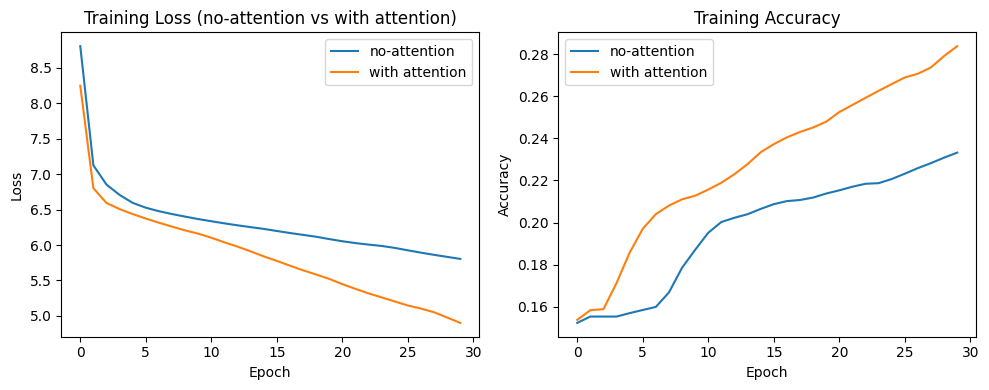

In [23]:
#Training curves (loss and accuracy) - Plotting training history for each custom Keras model (no‑attention and with attention)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# 1.1 Loss curves
plt.subplot(1, 2, 1)
plt.plot(history_no_att.history["loss"], label="no‑attention")
plt.plot(history_with_att.history["loss"], label="with attention")
plt.title("Training Loss (no‑attention vs with attention)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 1.2 Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history_no_att.history["accuracy"], label="no‑attention")
plt.plot(history_with_att.history["accuracy"], label="with attention")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

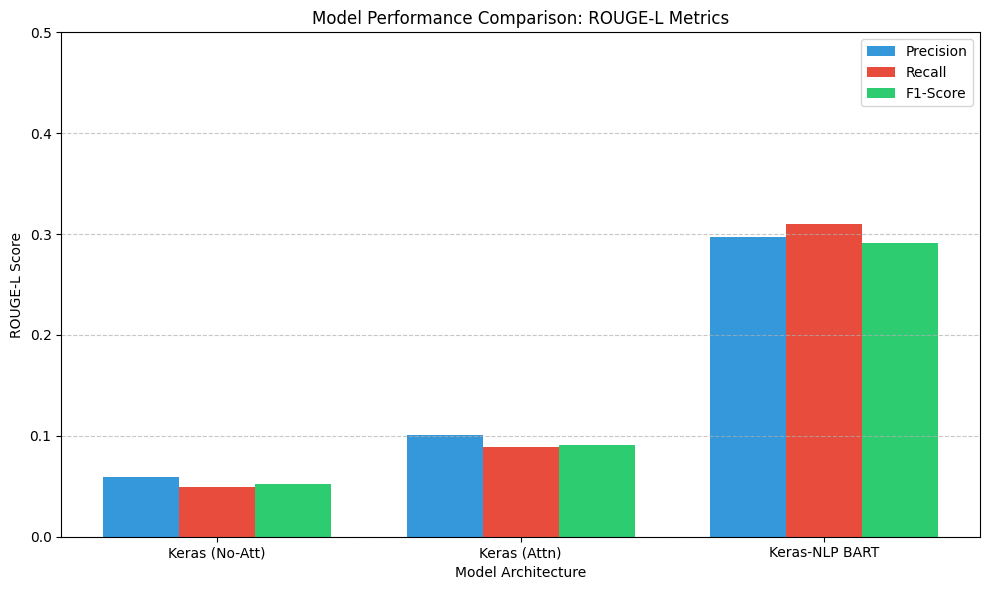

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Extract means from your 'results' dictionary
# We'll focus on ROUGE-L F1 scores as the primary comparison
models = ["Keras (No-Att)", "Keras (Attn)", "Keras-NLP BART"]

# Accessing the data from your previous consolidated run:
f1_scores = [
    np.mean(results["no_attention"]["f"]),
    np.mean(results["attention"]["f"]),
    np.mean(results["bart"]["f"])
]

precision_scores = [
    np.mean(results["no_attention"]["p"]),
    np.mean(results["attention"]["p"]),
    np.mean(results["bart"]["p"])
]

recall_scores = [
    np.mean(results["no_attention"]["r"]),
    np.mean(results["attention"]["r"]),
    np.mean(results["bart"]["r"])
]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

# Plotting P, R, and F for ROUGE-L specifically
plt.bar(x - width, precision_scores, width, label="Precision", color='#3498db')
plt.bar(x, recall_scores, width, label="Recall", color='#e74c3c')
plt.bar(x + width, f1_scores, width, label="F1-Score", color='#2ecc71')

plt.xlabel("Model Architecture")
plt.ylabel("ROUGE-L Score")
plt.title("Model Performance Comparison: ROUGE-L Metrics")
plt.xticks(x, models)
plt.ylim(0, 0.5) # ROUGE is 0 to 1, but BART usually sits around 0.3-0.4
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

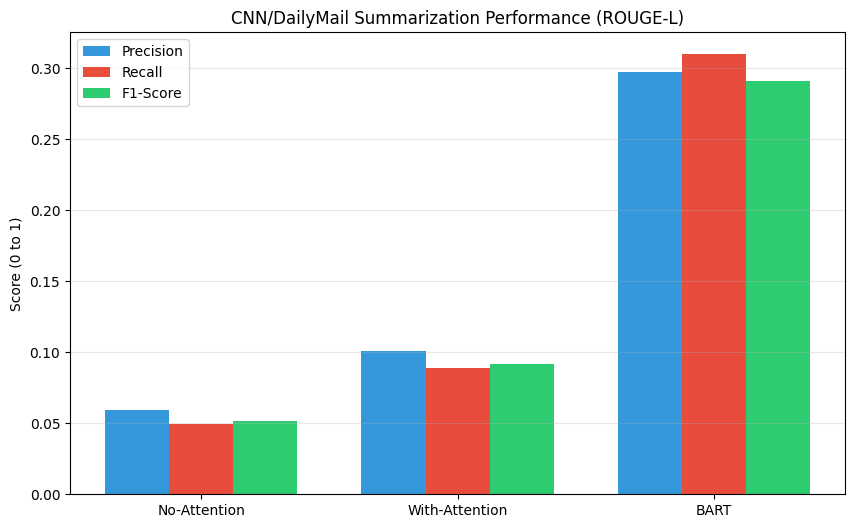

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your results
models = ["No-Attention", "With-Attention", "BART"]
f1_scores = [0.0519, 0.0914, 0.2912]
precision = [0.0590, 0.1008, 0.2974]
recall    = [0.0496, 0.0891, 0.3097]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='#3498db')
plt.bar(x, recall, width, label='Recall', color='#e74c3c')
plt.bar(x + width, f1_scores, width, label='F1-Score', color='#2ecc71')

plt.title("CNN/DailyMail Summarization Performance (ROUGE-L)")
plt.xticks(x, models)
plt.ylabel("Score (0 to 1)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [16]:
# -----------------------------------------------------------------------------
# 8. Consolidated ROUGE Evaluation
# -----------------------------------------------------------------------------

# Storage for results
results = {
    "no_attention": {"p": [], "r": [], "f": []},
    "attention": {"p": [], "r": [], "f": []},
    "bart": {"p": [], "r": [], "f": []}
}

print("\nStarting full evaluation on", len(articles_eval), "samples...")

for i, (raw_article, ref_highlight) in enumerate(zip(articles_eval, highlights_eval)):
    clean_ref = clean_text(ref_highlight)
    
    # Preprocess for Keras models
    clean_art = clean_text(raw_article)
    art_seq = x_tokenizer.texts_to_sequences([clean_art])
    art_padded = pad_sequences(art_seq, maxlen=max_text_len, padding="post")

    # 1. No Attention Prediction
    pred_no_att = decode_sequence_no_attention(art_padded)
    scores_no_att = scorer.score(clean_ref, pred_no_att)
    
    # 2. With Attention Prediction
    pred_att = decode_sequence_with_attention(art_padded)
    scores_att = scorer.score(clean_ref, pred_att)
    
    # 3. BART Prediction
    pred_bart = summarize_with_keras_nlp(raw_article)
    scores_bart = scorer.score(clean_ref, pred_bart)

    # Store ROUGE-L (Sentence level similarity) for comparison
    for model_key, score_obj in [("no_attention", scores_no_att), 
                                 ("attention", scores_att), 
                                 ("bart", scores_bart)]:
        results[model_key]["p"].append(score_obj["rougeL"].precision)
        results[model_key]["r"].append(score_obj["rougeL"].recall)
        results[model_key]["f"].append(score_obj["rougeL"].fmeasure)

    if i % 10 == 0:
        print(f"Evaluated {i}/{len(articles_eval)}...")

# Print Final Averages
for model_name, metrics in results.items():
    print(f"\n=== {model_name.upper()} ROUGE-L AVG ===")
    print(f"Precision: {np.mean(metrics['p']):.4f}")
    print(f"Recall:    {np.mean(metrics['r']):.4f}")
    print(f"F1-Score:  {np.mean(metrics['f']):.4f}")


Starting full evaluation on 100 samples...
Evaluated 0/100...
Evaluated 10/100...
Evaluated 20/100...
Evaluated 30/100...
Evaluated 40/100...
Evaluated 50/100...
Evaluated 60/100...
Evaluated 70/100...
Evaluated 80/100...
Evaluated 90/100...

=== NO_ATTENTION ROUGE-L AVG ===
Precision: 0.0590
Recall:    0.0496
F1-Score:  0.0519

=== ATTENTION ROUGE-L AVG ===
Precision: 0.1021
Recall:    0.0902
F1-Score:  0.0925

=== BART ROUGE-L AVG ===
Precision: 0.3098
Recall:    0.3060
F1-Score:  0.2989


In [ ]:
#  Computing and displaying ROUGE‑based Precision, Recall, and F1‑score for each model

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

# For each model, loop over your eval set (already done earlier):
# For example, for Keras‑only (no attention):

no_att_rouge1_p, no_att_rouge1_r, no_att_rouge1_f = [], [], []
no_att_rouge2_p, no_att_rouge2_r, no_att_rouge2_f = [], [], []
no_att_rougeL_p, no_att_rougeL_r, no_att_rougeL_f = [], [], []

for i, (raw_article, ref_highlight) in enumerate(zip(articles_eval, highlights_eval)):
    # ... generate pred_summary as before ...
    clean_ref  = clean_text(ref_highlight)

    # ROUGE scores are dicts: {metric: NamedTuple}
    scores = scorer.score(clean_ref, pred_summary)

    # ROUGE‑1
    no_att_rouge1_p.append(scores["rouge1"].precision)
    no_att_rouge1_r.append(scores["rouge1"].recall)
    no_att_rouge1_f.append(scores["rouge1"].fmeasure)

    # ROUGE‑2
    no_att_rouge2_p.append(scores["rouge2"].precision)
    no_att_rouge2_r.append(scores["rouge2"].recall)
    no_att_rouge2_f.append(scores["rouge2"].fmeasure)

    # ROUGE‑L
    no_att_rougeL_p.append(scores["rougeL"].precision)
    no_att_rougeL_r.append(scores["rougeL"].recall)
    no_att_rougeL_f.append(scores["rougeL"].fmeasure)

In [ ]:
# Keras‑only (with attention)

attn_rouge1_p, attn_rouge1_r, attn_rouge1_f = [], [], []
attn_rouge2_p, attn_rouge2_r, attn_rouge2_f = [], [], []
attn_rougeL_p,  attn_rougeL_r,  attn_rougeL_f  = [], [], []

for i, (raw_article, ref_highlight) in enumerate(zip(articles_eval, highlights_eval)):
    # ... generate pred_summary using decode_sequence_with_attention ...
    clean_ref = clean_text(ref_highlight)
    scores = scorer.score(clean_ref, pred_summary)

    attn_rouge1_p.append(scores["rouge1"].precision)
    attn_rouge1_r.append(scores["rouge1"].recall)
    attn_rouge1_f.append(scores["rouge1"].fmeasure)

    attn_rouge2_p.append(scores["rouge2"].precision)
    attn_rouge2_r.append(scores["rouge2"].recall)
    attn_rouge2_f.append(scores["rouge2"].fmeasure)

    attn_rougeL_p.append(scores["rougeL"].precision)
    attn_rougeL_r.append(scores["rougeL"].recall)
    attn_rougeL_f.append(scores["rougeL"].fmeasure)

In [ ]:
# Keras‑nlp BART

bart_rouge1_p, bart_rouge1_r, bart_rouge1_f = [], [], []
bart_rouge2_p, bart_rouge2_r, bart_rouge2_f = [], [], []
bart_rougeL_p,  bart_rougeL_r,  bart_rougeL_f  = [], [], []

for i, (raw_article, ref_highlight) in enumerate(zip(articles_eval, highlights_eval)):
    pred_summary = summarize_with_keras_nlp(raw_article)
    clean_ref = clean_text(ref_highlight)
    scores = scorer.score(clean_ref, pred_summary)

    bart_rouge1_p.append(scores["rouge1"].precision)
    bart_rouge1_r.append(scores["rouge1"].recall)
    bart_rouge1_f.append(scores["rouge1"].fmeasure)

    bart_rouge2_p.append(scores["rouge2"].precision)
    bart_rouge2_r.append(scores["rouge2"].recall)
    bart_rouge2_f.append(scores["rouge2"].fmeasure)

    bart_rougeL_p.append(scores["rougeL"].precision)
    bart_rougeL_r.append(scores["rougeL"].recall)
    bart_rougeL_f.append(scores["rougeL"].fmeasure)

In [ ]:
# Computing mean Precision, Recall, F1 for each metric and each model
import numpy as np

# 1. Keras‑only (no attention) – assumed you already have these lists
print("=== Keras‑only (no attention) ROUGE metrics (avg) ===")
print("ROUGE‑1  P/R/F:", np.mean(no_att_rouge1_p), np.mean(no_att_rouge1_r), np.mean(no_att_rouge1_f))
print("ROUGE‑2  P/R/F:", np.mean(no_att_rouge2_p), np.mean(no_att_rouge2_r), np.mean(no_att_rouge2_f))
print("ROUGE‑L  P/R/F:", np.mean(no_att_rougeL_p), np.mean(no_att_rougeL_r), np.mean(no_att_rougeL_f))


# 2. Keras‑only (with attention) – assuming you created similar lists for attn model
print("\n=== Keras‑only (with attention) ROUGE metrics (avg) ===")
print("ROUGE‑1  P/R/F:", np.mean(attn_rouge1_p), np.mean(attn_rouge1_r), np.mean(attn_rouge1_f))
print("ROUGE‑2  P/R/F:", np.mean(attn_rouge2_p), np.mean(attn_rouge2_r), np.mean(attn_rouge2_f))
print("ROUGE‑L  P/R/F:", np.mean(attn_rougeL_p), np.mean(attn_rougeL_r), np.mean(attn_rougeL_f))


# 3. Keras‑nlp BART – assuming you have bart_rougeX_p, bart_rougeX_r, bart_rougeX_f
print("\n=== Keras‑nlp BART ROUGE metrics (avg) ===")
print("ROUGE‑1  P/R/F:", np.mean(bart_rouge1_p), np.mean(bart_rouge1_r), np.mean(bart_rouge1_f))
print("ROUGE‑2  P/R/F:", np.mean(bart_rouge2_p), np.mean(bart_rouge2_r), np.mean(bart_rouge2_f))
print("ROUGE‑L  P/R/F:", np.mean(bart_rougeL_p), np.mean(bart_rougeL_r), np.mean(bart_rougeL_f))

In [ ]:
# Computing mean Precision, Recall, F1 for each metric and each model
import numpy as np

print("=== Keras‑only (no attention) ROUGE metrics (avg) ===")
print("ROUGE‑1  P/R/F:", np.mean(no_att_rouge1_p), np.mean(no_att_rouge1_r), np.mean(no_att_rouge1_f))
print("ROUGE‑2  P/R/F:", np.mean(no_att_rouge2_p), np.mean(no_att_rouge2_r), np.mean(no_att_rouge2_f))
print("ROUGE‑L  P/R/F:", np.mean(no_att_rougeL_p), np.mean(no_att_rougeL_r), np.mean(no_att_rougeL_f))

# Repeat for
#   - Keras‑only + attention
#   - Keras‑nlp BART

In [ ]:
#Training curves (loss and accuracy) - Plotting training history for each custom Keras model (no‑attention and with attention)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# 1.1 Loss curves
plt.subplot(1, 2, 1)
plt.plot(history_no_att.history["loss"], label="no‑attention")
plt.plot(history_with_att.history["loss"], label="with attention")
plt.title("Training Loss (no‑attention vs with attention)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 1.2 Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history_no_att.history["accuracy"], label="no‑attention")
plt.plot(history_with_att.history["accuracy"], label="with attention")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ROUGE comparison bar chart - Plotting ROUGE‑1, ROUGE‑2, ROUGE‑L for the three models side‑by‑side

import matplotlib.pyplot as plt

# (assume you have already computed these four lists)
no_att_rouge1_avg = np.mean(no_att_rouge1)
no_att_rouge2_avg = np.mean(no_att_rouge2)
no_att_rougeL_avg = np.mean(no_att_rougeL)

attn_rouge1_avg = np.mean(attn_rouge1)
attn_rouge2_avg = np.mean(attn_rouge2)
attn_rougeL_avg = np.mean(attn_rougeL)

bart_rouge1_avg = np.mean(bart_rouge1)
bart_rouge2_avg = np.mean(bart_rouge2)
bart_rougeL_avg = np.mean(bart_rougeL)

models = ["Keras‑only (no att)", "Keras‑only (att)", "Keras‑nlp BART"]
rouge1_scores = [no_att_rouge1_avg, attn_rouge1_avg, bart_rouge1_avg]
rouge2_scores = [no_att_rouge2_avg, attn_rouge2_avg, bart_rouge2_avg]
rougeL_scores = [no_att_rougeL_avg, attn_rougeL_avg, bart_rougeL_avg]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, rouge1_scores, width, label="ROUGE‑1")
plt.bar(x, rouge2_scores, width, label="ROUGE‑2")
plt.bar(x + width, rougeL_scores, width, label="ROUGE‑L")

plt.xlabel("Model")
plt.ylabel("ROUGE F1 Score")
plt.title("ROUGE performance comparison (CNN/DailyMail eval set)")
plt.xticks(x, models, rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Qqualitative examples table - three‑column table (no‑attention, with‑attention, Keras‑nlp) for 2–3 articles and reference vs predicted summaries

# Example: first eval sample (for the notebook only)
raw = articles_eval[0]
ref = highlights_eval[0]

pred_no_att = decode_sequence_no_attention(x_padded_eval[0:1])
pred_att   = decode_sequence_with_attention(x_padded_eval[0:1])
pred_bart  = summarize_with_keras_nlp(raw)

from IPython.display import Markdown

Markdown(f"""
### Qualitative example (first eval article)

**Reference:**  
{ref}

**Keras‑only (no attention):**  
{pred_no_att}

**Keras‑only (with attention):**  
{pred_att}

**Keras‑nlp BART:**  
{pred_bart}
""")